# Chatbot with HITL (Human in the Loop)

Agent 처리도중 사람의 개입이 필요한 경우 iterrupt처리할 수 있다.
- 사람의 개입(tool)
- 사람 메세지(command)로 대화를 재개할 수 있다.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
# Tavily 도구 생성
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

## 사람 개입 도구

In [3]:
from langchain_core.tools import tool # Tool 데코레이터
from langgraph.types import interrupt # 사람 응답을 기다리는 interrupt

@tool
def human_assist(query: str) -> str:
    """
    매장 정보만으로 답할 수 없는 메뉴·재고·구매 가능 여부를 매니저에게 확인합니다. 
    """
    human_response = interrupt({'query': query}) # 실행을 중단하고 Command(resume=...) 값으로 재개
    return human_response['data'] # 사람의 응답 데이터

In [4]:
from typing import TypedDict, Annotated, List       # 타입 힌트 도구
from langgraph.graph.message import add_messages    # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    # messages 필드가 add_messages 규칙으로 누적 저장
    messages: Annotated[List, add_messages] 

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool, human_assist]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 바인딩

# State의 messages 를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    # 누적된 메시지 리스트로 LLM 호출
    response = llm_with_tools.invoke(state['messages']) 
    # add_messages 규칙에 의해 기존 messages에 응답이 누적됨. 
    return {'messages': [response]}    


In [5]:
# 메모리 기반 체크포인트 저장소 ( 인메모리 )
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # 상태 체크포인트를 RAM에 저장하는 객체

<class 'langgraph.graph.state.CompiledStateGraph'>


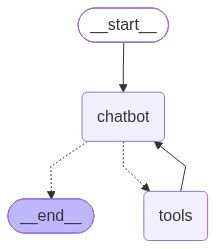

In [6]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# State 스키마 기반 그래프 설계 객체 생성
builder = StateGraph(State) 
tool_node = ToolNode(tools)

# 시작 노드 -> chatbot 노드
builder.add_edge(START, 'chatbot') 

builder.add_node('chatbot', chatbot) # chatbot 노드
builder.add_node('tools', tool_node) # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools','chatbot')

graph = builder.compile(checkpointer = memory) # 체크포인터를 포함하여 실행 가능한 그래프로 컴파일
print(type(graph)) # 그래프 타입 확인
graph # 그래프 객체

## 챗봇 실행

In [7]:
from pprint import pprint

# 스냅샷 출력 함수 : 저장된 상태(messages)와 다음 실행 노드(next) 확인
def print_snapshot(graph, config):
    snapshot = graph.get_state(config) # 해당 config(thread_id)의 스냅샷 조회

    if 'messages' in snapshot.values:      # messages 가 존재하면
        pprint(snapshot.values['messages']) # 누적된 messages 출력
    else:
        print("메시지가 없음!")
    print(f"Next: {snapshot.next}") # 다음 실행 노드 출력 (튜플)

print(print_snapshot(graph, {'configurable': {'thread_id': 'user1'}}))

메시지가 없음!
Next: ()
None


In [8]:
user1_config = {'configurable' : {'thread_id': 'user1'}}

state = {'messages' : [('human', 'langgraph 를 멀티에이전트 설계에서 사용하는 이유는 뭐야?')]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = graph.invoke(state, user1_config) 
print(response['messages'][-1].content)

LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트들 간의 복잡한 흐름을 “그래프”로 명확하게 제어할 수 있기 때문**입니다.  
단순히 여러 LLM을 붙여놓는 것보다, **상태 관리, 분기, 반복, 협업, 오류 처리**를 체계적으로 만들기 좋습니다.

핵심 이유를 정리하면:

### 1) 에이전트 간 흐름을 유연하게 설계 가능
멀티에이전트는 보통
- 어떤 에이전트가 먼저 일할지
- 결과를 누가 검토할지
- 실패하면 어디로 돌아갈지
- 언제 종료할지

같은 흐름 제어가 중요한데, LangGraph는 이를 **노드와 엣지**로 표현해서 쉽게 관리할 수 있습니다.

### 2) 상태를 공유하고 누적하기 좋음
에이전트들이 각자 독립적으로만 움직이면 협업이 어렵습니다.  
LangGraph는 **공유 state**를 중심으로 동작해서,

- 이전 에이전트의 결과를 다음 에이전트가 이어받고
- 중간 판단을 누적하고
- 대화/작업 맥락을 유지

하기 좋습니다.

### 3) 순환 구조와 반복 작업에 강함
멀티에이전트는 한 번에 끝나지 않고,
- 검토 → 수정 → 재검토
- 계획 → 실행 → 평가 → 재계획

처럼 **루프**가 자주 생깁니다.  
LangGraph는 이런 **cyclic workflow**를 자연스럽게 지원합니다.

### 4) 조건부 분기와 라우팅이 쉬움
예를 들어:
- 사용자가 기술 질문이면 Research Agent로
- 코드 문제가 있으면 Coding Agent로
- 결과가 불충분하면 다시 검색

이런 식의 **조건 분기**를 깔끔하게 넣을 수 있습니다.  
멀티에이전트에서 중요한 “누가 다음에 일할지”를 제어하기 좋습니다.

### 5) 디버깅과 가시성이 좋음
에이전트 시스템은 복잡해지면 왜 그런 결론이 나왔는지 추적하기 어려운데,  
LangGraph는 구조가 명확해서

- 어떤 노드를 거쳤는지
- 어떤 state가 바뀌었는지
- 어디서 실패했는지

를 추적하기 쉬운 편입니다.

### 6) 역할 분담형 에이전트 구조와 잘 맞음

In [9]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph 를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='46c51722-e51a-45a8-b8ff-8a0231da2bed'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트들 간의 복잡한 흐름을 “그래프”로 명확하게 제어할 수 있기 때문**입니다.  \n단순히 여러 LLM을 붙여놓는 것보다, **상태 관리, 분기, 반복, 협업, 오류 처리**를 체계적으로 만들기 좋습니다.\n\n핵심 이유를 정리하면:\n\n### 1) 에이전트 간 흐름을 유연하게 설계 가능\n멀티에이전트는 보통\n- 어떤 에이전트가 먼저 일할지\n- 결과를 누가 검토할지\n- 실패하면 어디로 돌아갈지\n- 언제 종료할지\n\n같은 흐름 제어가 중요한데, LangGraph는 이를 **노드와 엣지**로 표현해서 쉽게 관리할 수 있습니다.\n\n### 2) 상태를 공유하고 누적하기 좋음\n에이전트들이 각자 독립적으로만 움직이면 협업이 어렵습니다.  \nLangGraph는 **공유 state**를 중심으로 동작해서,\n\n- 이전 에이전트의 결과를 다음 에이전트가 이어받고\n- 중간 판단을 누적하고\n- 대화/작업 맥락을 유지\n\n하기 좋습니다.\n\n### 3) 순환 구조와 반복 작업에 강함\n멀티에이전트는 한 번에 끝나지 않고,\n- 검토 → 수정 → 재검토\n- 계획 → 실행 → 평가 → 재계획\n\n처럼 **루프**가 자주 생깁니다.  \nLangGraph는 이런 **cyclic workflow**를 자연스럽게 지원합니다.\n\n### 4) 조건부 분기와 라우팅이 쉬움\n예를 들어:\n- 사용자가 기술 질문이면 Research Agent로\n- 코드 문제가 있으면 Coding Agent로\n- 결과가 불충분하면 다시 검색\n\n이런 식의 **조건 분기**를 깔끔하게 넣을 수 있습니다.  \n멀티에

### 케이크 샵 챗봇

In [10]:
from langchain_core.prompts import ChatPromptTemplate

system_prompt = """
**Instruction**
사용자는 케이크 주문, 메뉴 문의, 매장 정보 등을 챗봇에 요청할 수 있다.
챗봇은 친절하고 정확하게 답변한다.

**Context**
당신은 프리미엄 케이크샵의 공식 챗봇이다.
- 운영 시간: 매일 09:00–21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

**Example**
> **User:** “다음 주 수요일 오후 3시에 케이크 예약 가능한가요?”
> **Bot:** “안녕하세요! 다음 주 수요일(2025년 7월 16일) 오후 3시에 예약 가능합니다. 예약을 원하시면 성함과 연락처를 알려주세요.”

**Output Indicator**
- 챗봇 응답은 한 문단 이내로 간결하게 제시한다.
- 필요한 경우 날짜·시간은 YYYY년 M월 D일 형식으로 명시한다.
- 추가 질문이 필요할 때에는 “추가로 궁금하신 점이 있으면 말씀해주세요.” 로 마무리한다.
- 그외 답변하기 어려운 경우, human_assist 도구를 사용하여 인간의 도움을 요청한다.
"""  # 시스템 지침/컨텍스트/출력 규칙 정의

user_prompt = '당근케익 4호가 홈페이지에서 구매가 안되는데, 매니져님께 구매가능여부를 묻고 싶어요.'  # 사용자 요청 문장

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', '{user_prompt}')
])

state  = {'messages' : prompt.format_messages(user_prompt = user_prompt)}
response = graph.invoke(state, user1_config)
print(response['messages'][-1].content)

In [11]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph 를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='46c51722-e51a-45a8-b8ff-8a0231da2bed'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트들 간의 복잡한 흐름을 “그래프”로 명확하게 제어할 수 있기 때문**입니다.  \n단순히 여러 LLM을 붙여놓는 것보다, **상태 관리, 분기, 반복, 협업, 오류 처리**를 체계적으로 만들기 좋습니다.\n\n핵심 이유를 정리하면:\n\n### 1) 에이전트 간 흐름을 유연하게 설계 가능\n멀티에이전트는 보통\n- 어떤 에이전트가 먼저 일할지\n- 결과를 누가 검토할지\n- 실패하면 어디로 돌아갈지\n- 언제 종료할지\n\n같은 흐름 제어가 중요한데, LangGraph는 이를 **노드와 엣지**로 표현해서 쉽게 관리할 수 있습니다.\n\n### 2) 상태를 공유하고 누적하기 좋음\n에이전트들이 각자 독립적으로만 움직이면 협업이 어렵습니다.  \nLangGraph는 **공유 state**를 중심으로 동작해서,\n\n- 이전 에이전트의 결과를 다음 에이전트가 이어받고\n- 중간 판단을 누적하고\n- 대화/작업 맥락을 유지\n\n하기 좋습니다.\n\n### 3) 순환 구조와 반복 작업에 강함\n멀티에이전트는 한 번에 끝나지 않고,\n- 검토 → 수정 → 재검토\n- 계획 → 실행 → 평가 → 재계획\n\n처럼 **루프**가 자주 생깁니다.  \nLangGraph는 이런 **cyclic workflow**를 자연스럽게 지원합니다.\n\n### 4) 조건부 분기와 라우팅이 쉬움\n예를 들어:\n- 사용자가 기술 질문이면 Research Agent로\n- 코드 문제가 있으면 Coding Agent로\n- 결과가 불충분하면 다시 검색\n\n이런 식의 **조건 분기**를 깔끔하게 넣을 수 있습니다.  \n멀티에

In [ ]:
# 사람 개입
from langgraph.types import Command # interrupt를 재개(resume) 하기 위한 Command

human_response = "물론입니다. 구매 가능하시고요. 홈페이지 구매 가능하도록 채널 열어놓겠습니다. 가격은 15만원 입니다. 감사합니다."

command = Command(resume={'data' : human_response}) # interrupt에 전달할 재개 메시지 
response = graph.invoke(command, user1_config) # 중단된 그래프를 thread_id user1 에서 재개 실행
print(response['messages'][-1].content)

안녕하세요! 당근케익 4호는 구매 가능하며, 홈페이지 주문도 가능하도록 처리해두겠습니다. 가격은 15만원입니다. 추가로 궁금하신 점이 있으면 말씀해주세요.


In [13]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph 를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='46c51722-e51a-45a8-b8ff-8a0231da2bed'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는, **에이전트들 간의 복잡한 흐름을 “그래프”로 명확하게 제어할 수 있기 때문**입니다.  \n단순히 여러 LLM을 붙여놓는 것보다, **상태 관리, 분기, 반복, 협업, 오류 처리**를 체계적으로 만들기 좋습니다.\n\n핵심 이유를 정리하면:\n\n### 1) 에이전트 간 흐름을 유연하게 설계 가능\n멀티에이전트는 보통\n- 어떤 에이전트가 먼저 일할지\n- 결과를 누가 검토할지\n- 실패하면 어디로 돌아갈지\n- 언제 종료할지\n\n같은 흐름 제어가 중요한데, LangGraph는 이를 **노드와 엣지**로 표현해서 쉽게 관리할 수 있습니다.\n\n### 2) 상태를 공유하고 누적하기 좋음\n에이전트들이 각자 독립적으로만 움직이면 협업이 어렵습니다.  \nLangGraph는 **공유 state**를 중심으로 동작해서,\n\n- 이전 에이전트의 결과를 다음 에이전트가 이어받고\n- 중간 판단을 누적하고\n- 대화/작업 맥락을 유지\n\n하기 좋습니다.\n\n### 3) 순환 구조와 반복 작업에 강함\n멀티에이전트는 한 번에 끝나지 않고,\n- 검토 → 수정 → 재검토\n- 계획 → 실행 → 평가 → 재계획\n\n처럼 **루프**가 자주 생깁니다.  \nLangGraph는 이런 **cyclic workflow**를 자연스럽게 지원합니다.\n\n### 4) 조건부 분기와 라우팅이 쉬움\n예를 들어:\n- 사용자가 기술 질문이면 Research Agent로\n- 코드 문제가 있으면 Coding Agent로\n- 결과가 불충분하면 다시 검색\n\n이런 식의 **조건 분기**를 깔끔하게 넣을 수 있습니다.  \n멀티에